### $$\underline{\text{DHF : Lab 4}}$$ 

##### $$\text{Arnaud Capitan, Vasco Nappa, Achraf Ouboujemaa}$$ 
___



### Librairies

In [1]:
import pandas as pd
import numpy as np
from scipy.optimize import minimize_scalar
from scipy import stats
from scipy import optimize
import matplotlib.pyplot as plt

___

### Data Loading

In [2]:
stock_ids = ["0","1","2"]
day_ids = ["0","1","2","3","4"]
extensions = ["updates","trades"]

trades = np.zeros((len(stock_ids), len(day_ids)), dtype=pd.DataFrame)
updates = np.zeros((len(stock_ids), len(day_ids)), dtype=pd.DataFrame)

def get_data_path(stock_id, day, extension):
    return f"Data/stock{stock_id}_day{day}_{extension}.csv.gz"

for stock_id in stock_ids :
    for day_id in day_ids :
        data_path_updates = get_data_path(stock_id, day_id, "updates")
        data_path_trades = get_data_path(stock_id, day_id, "trades")
        df_updates = pd.read_csv(data_path_updates)
        df_trades = pd.read_csv(data_path_trades)
        df_updates["ts"] = pd.to_datetime(df_updates["ts"])
        df_trades["ts"] = pd.to_datetime(df_trades["ts"])
        updates[stock_ids.index(stock_id), day_ids.index(day_id)] = df_updates
        trades[stock_ids.index(stock_id), day_ids.index(day_id)] = df_trades

### Test of data loading :

In [3]:
print(updates[0,0].head())

                          ts type  bp       bq  ap       aq
0 2026-01-26 09:00:00.340497    U NaN  19671.0 NaN  24789.0
1 2026-01-26 09:00:00.503532    U NaN  19671.0 NaN  24789.0
2 2026-01-26 09:00:00.503539    U NaN  19671.0 NaN  24789.0
3 2026-01-26 09:00:00.503565    U NaN  19671.0 NaN  24789.0
4 2026-01-26 09:00:00.503735    U NaN  19671.0 NaN  24789.0


In [4]:
print(trades[0,0].head())

   price  qty                         ts
0  55.00    2 2026-01-26 09:00:27.018202
1  55.00   10 2026-01-26 09:00:27.018202
2  55.00   10 2026-01-26 09:00:27.018202
3  54.97  446 2026-01-26 09:00:27.041728
4  54.97   24 2026-01-26 09:00:27.042153


___

### Lab 4 : Questions

___

### 1. Brownian motions with Poisson sampling

We take the functions used to answer question 2 of Lab 2 :

In [5]:
def exponential_variable(lambda_intensity):
    u = np.random.uniform(0,1)
    s = -np.log(1-u)/lambda_intensity
    return s

def homogeneous_poisson_process(lambda_intensity,T):
    t = 0
    i = 1
    L = []
    s = exponential_variable(lambda_intensity)
    while t+s < T:
        t = t + s
        L.append(t)
        s = exponential_variable(lambda_intensity)
    return L

In lab 2 we considered two processes $p_i (t) = \sigma _i W_i (t)$, $i = 1,2$ where $W_1$ and $W_2$ are two Brownian motions such that : 

$<W_1,W_2>_t = \rho t$ for some constants $\sigma _1 >0$, $\sigma _2 >0$ and $\rho \in ]-1,1[$

Furthermore, we observe each process $p_i$ on $[0,T]$ at times $T_{i,k}, k \geq 0$ with $T_{i,k}$ being a Poisson process with constant intensity $\mu _i$

In [6]:
sigma1 = 0.8
sigma2 = 0.6
rho = 3/7
mu1 = 3
mu2 = 4
T = 100

Since we will need to observe our brownian motions $p_1$ and $p_2$ and random times, we need a lot of data points for both our brownian motions to make sure we can observe their values at the $T_{i,k}$ generated.

In [7]:
def p1_p2(sigma1,sigma2,rho,T,N_times = 100000):
    dt = T/N_times
    times = np.linspace(0,T,N_times+1)
    dW1 = np.random.normal(0, np.sqrt(dt),N_times) #sqrt(t) for the standard deviation, to get t as variance
    dW2 = rho*dW1 + np.sqrt(1-rho**2)*np.random.normal(0,np.sqrt(dt),N_times)
    W1 = np.concatenate([[0],np.cumsum(dW1)])
    W2 = np.concatenate([[0],np.cumsum(dW2)])
    p1 = sigma1*W1
    p2 = sigma2*W2
    return(times,p1,p2)

def observation_times_p1_p2(mu1,mu2,T):
    T1 = homogeneous_poisson_process(mu1,T)
    T2 = homogeneous_poisson_process(mu2,T)
    return(T1,T2)

def observe_p1_p2(p1,p2,T1,T2,times):
    indices1 = np.clip(np.searchsorted(times,T1,side='right')-1,0,len(p1)-1)
    indices2 = np.clip(np.searchsorted(times,T2,side='right')-1,0,len(p2)-1)
    return (p1[indices1],p2[indices2])

We will now simulate multiple sample paths of the observed processes (based on the random observation times), and then compute for each path the standard covariance estimator of $[p_1,p_2]_T = \rho \sigma _1 \sigma _2 T$ for various sampling periods $\tau$

___ 

The (deterministic) covariation of $p_1$ and $p_2$ is given by :

$ <p_1,p_2> _T = \int _0 ^T \sigma ^1 _t \sigma ^2 _t \rho _t dt$

By replacing the deterministic values above by our constant values, we get the result mentioned in lab 2 : $[p_1,p_2]_T = \rho \sigma _1 \sigma _2 T$

Note that for correlated continuous Brownian motions (hypothesis that we will consider verified given our case study) we have $[p_1,p_2]_T = <p_1,p_2>_T$

We have the Hayashi-Yoshida covariance estimator :

$\widehat{[p_1,p_2]_T} = \sum _{i=1} ^{n_1} \sum _{j=1} ^{n_2} \Delta p_1(T_{1,i}) \cdot \Delta p_2(T_{2,j}) \cdot \mathbf{1} [(T_{1,i-1}, T_{1,i}] \cap (T_{2,j-1}, T_{2,j}] \neq \emptyset]$

In [8]:
def sample_grid_tau(T_obs,p_obs,tau,T):
    n = int(T/tau)
    p_grid = np.full(n+1,np.nan)
    for k in range(n+1):
        idx = np.searchsorted(T_obs,k*tau,side='right')-1
        if idx >= 0:
            p_grid[k] = p_obs[idx]
    return(p_grid)

def standard_covariance_estimator_lab2_q2(T1,T2,p1,p2,times,tau):
    p1_obs, p2_obs = observe_p1_p2(p1,p2,T1,T2,times)
    p1_grid = sample_grid_tau(T1,p1_obs,tau,T)
    p2_grid = sample_grid_tau(T2,p2_obs,tau,T)
    dp1 = np.diff(p1_grid)
    dp2 = np.diff(p2_grid)
    mask = np.logical_not(np.logical_or(np.isnan(dp1),np.isnan(dp2)))
    return np.sum(dp1[mask]*dp2[mask])

def hayashi_yoshida_covariance_estimator_lab2_q2(T1,T2,p1,p2,times):
    n1 = len(T1)
    n2 = len(T2)
    p1_obs, p2_obs = observe_p1_p2(p1,p2,T1,T2,times)
    estimator = 0
    for i in range(1,n1):
        for j in range(1,n2):
            if not (T2[j] < T1[i-1] or T1[i] < T2[j-1]): # For [t1,t2] and [t3,t4], if t2 < t3 or t4 < t1, no intersection
                delta_p1 = p1_obs[i]-p1_obs[i-1]
                delta_p2 = p2_obs[j]-p2_obs[j-1]
                estimator = estimator + delta_p1*delta_p2
    return(estimator)

___

Covariance computation :

In [9]:
true_covariance_value = rho*sigma1*sigma2*T
N_paths = 200
tau_values = [0.01,0.1,0.2,0.5,1,2,3,5,8,10]

hayashi_yoshida_estimate_list = []
results = {}
for tau in tau_values:
    results[tau] = []

for _ in range(N_paths):
    times,p1,p2 = p1_p2(sigma1,sigma2,rho,T)
    T1,T2 = observation_times_p1_p2(mu1,mu2,T)
    hayashi_yoshida_estimate = hayashi_yoshida_covariance_estimator_lab2_q2(T1,T2,p1,p2,times)
    hayashi_yoshida_estimate_list.append(hayashi_yoshida_estimate)
    for tau in tau_values:
        standard_covariance_estimate = standard_covariance_estimator_lab2_q2(T1,T2,p1,p2,times,tau)
        results[tau].append(standard_covariance_estimate)

means_standard_estimate = [np.mean(results[tau]) for tau in tau_values]
stds_standard_estimate = [np.std(results[tau]) for tau in tau_values]
hy_mean = np.mean(np.asarray(hayashi_yoshida_estimate_list))
hy_95_ci = 1.96*np.std(np.asarray(hayashi_yoshida_estimate_list)) / np.sqrt(N_paths)

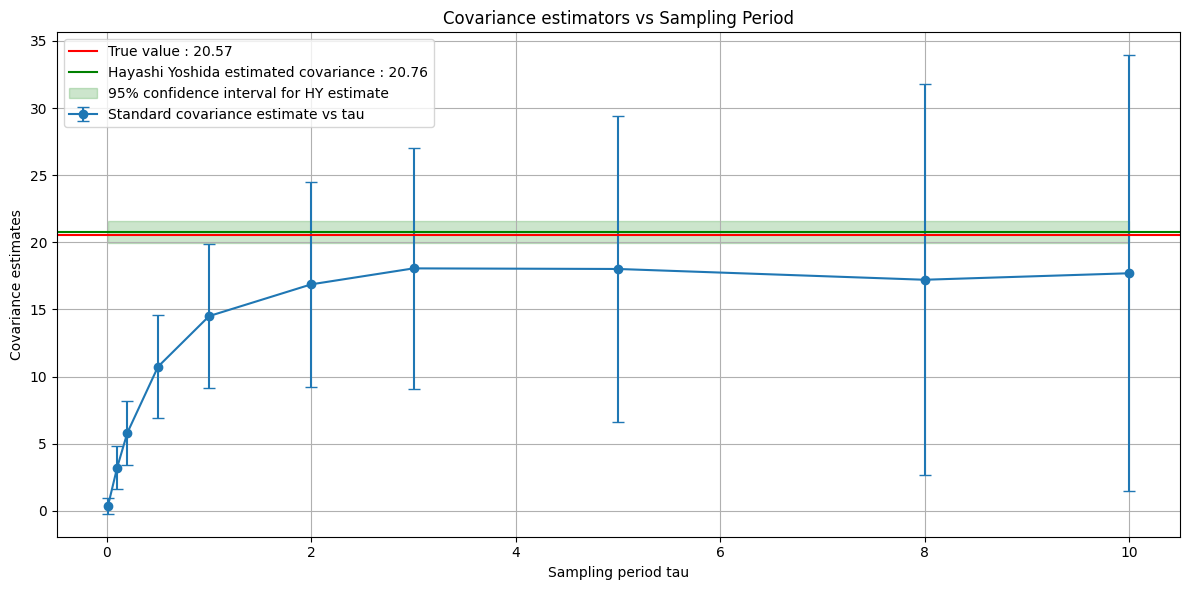

In [10]:
plt.figure(figsize=(12,6))
plt.errorbar(tau_values,means_standard_estimate,yerr=stds_standard_estimate,fmt='o-',capsize=4,label="Standard covariance estimate vs tau")
plt.axhline(true_covariance_value, color='r', label=f"True value : {true_covariance_value:.2f}")
plt.axhline(hy_mean, color='green', label=f"Hayashi Yoshida estimated covariance : {hy_mean:.2f}")
plt.fill_between(tau_values,hy_mean-hy_95_ci,hy_mean+hy_95_ci,color='green',alpha=0.2,label="95% confidence interval for HY estimate")
plt.xlabel("Sampling period tau")
plt.ylabel("Covariance estimates")
plt.title("Covariance estimators vs Sampling Period")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Looking at the result, we have that :

For a small $\tau$ value, the estimator is close to 0 with a very low standard deviation, which means it is highly biased since it is not the expected value. This can be explained with the fact that since the two brown are rarely observed in the same time window, the brownian motions (or assets) appear uncorrelated : we expected this result as explained before, since no changes were captured by the random observation times on both assets during the same observation window because of the sampling period, we just sum terms that are equal to 0.

For a big $\tau$ value, the estimator converges to the expected value $\rho \sigma _1 \sigma _2 T$, but with a very high standard deviation.

This effect of having two correlated assets being seemingly uncorrelated from random discrete observations (for $\tau$ value being low) is called the **Epps effect**, and it suggests that there is an optimal $\tau$ such that our estimator is close to the expected value while retaining a small variance.

In our case, even with $\tau = 5$ where it seems to yield the best results, the standard deviation is so high that estimation may fail to meet the expected value.

On the other hand, the **Hayashi-Yoshida estimator** yields great results, as it estimates efficiently the expected value.

___

### 2. Signature plots and Epps effect

We will consider that over the period of 5 days for which we consider our 3 different stocks, we consider the driftless stochastic volatility model for our log-price :

$\log(S_t) = p(t) = \int _0 ^t \sigma _s dB_s \qquad t \in [0,T]$

By definition, the integrated realized variance is : $\quad IV = [p]_T = \int _0 ^T \sigma _t ^2 dt$

And the normalized integrated realized variance is : $\quad \dfrac{1}{T} \int _0 ^T \sigma _t ^2 dt$

We wish to estimate the integrated realized variance for each stock, and the correlation using the standard covariance estimator and the Hayashi-Yoshida covariance estimator : since correlation is covariance normalized by the variance, we can use the covariance estimators then normalize them using the variance estimators we will have previously computed.

For a given sampling period $\tau$, we have the realized variance estimator :

$ RV(\tau) = \sum _{i=1} ^{\lfloor T / \tau \rfloor} (p(i\tau)-p((i-1)\tau))^2$

In [11]:
def integrated_realized_variance_estimator(trade_df,tau):
    t0 = trade_df["ts"].iloc[0]
    T = (trade_df["ts"].iloc[-1]-t0).total_seconds()
    T_obs = (trade_df["ts"]-t0).dt.total_seconds().values
    p_obs = np.log(trade_df["price"].values)
    m = int(T/tau)
    realized_variance = 0
    for i in range (1,m+1):
        idx_i_tau = np.searchsorted(T_obs,i*tau,side='right')-1
        idx_i_minus_one_tau = np.searchsorted(T_obs,(i-1)*tau,side='right')-1
        if idx_i_minus_one_tau < 0 or idx_i_tau < 0:
            continue
        realized_variance += (p_obs[idx_i_tau]-p_obs[idx_i_minus_one_tau])**2
    return realized_variance

Since we have that $RV(\tau) _{\tau \rightarrow 0} \rightarrow  IV$ in probability from the course, $RV(\tau)$ is a consistent estimator of the integrated variance.

We take some small values for our sampling period $\tau$ and we expect to have convergence. 

In [12]:
tau_values = [0.01,0.02,0.05,0.1,0.2,0.5,1,2,5,6,7,8,9,10,20,50,100]

results_rv = [] # standard realized variance without tau period
for stock in range(len(stock_ids)):
    rv = 0
    for day in range(len(day_ids)):
        df = trades[stock,day]
        rv += np.sum(np.diff(np.log(df["price"].values))**2)
    results_rv.append(rv/len(day_ids))

results_rv_tau = {} # realized variance with tau period
for stock in range (len(stock_ids)):
    print(f"Stock {stock+1} computation...")
    stock_rv = []
    for tau in tau_values:
        L = []
        for day in range (len(day_ids)):
            df = trades[stock,day]
            rv = integrated_realized_variance_estimator(df,tau)
            L.append(rv)
        stock_rv.append(np.mean(L))
    results_rv_tau[stock] = stock_rv

Stock 1 computation...
Stock 2 computation...
Stock 3 computation...


We will be using log-scale for the x-axis as we expect the integrated realized variance to converge as $\tau$ goes to 0.

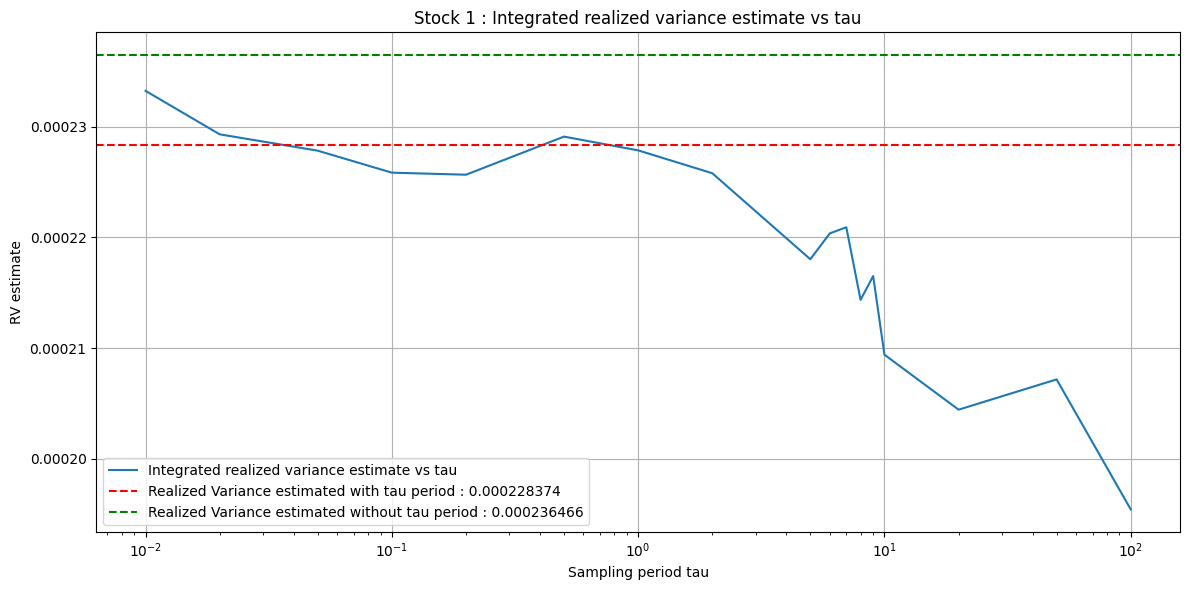

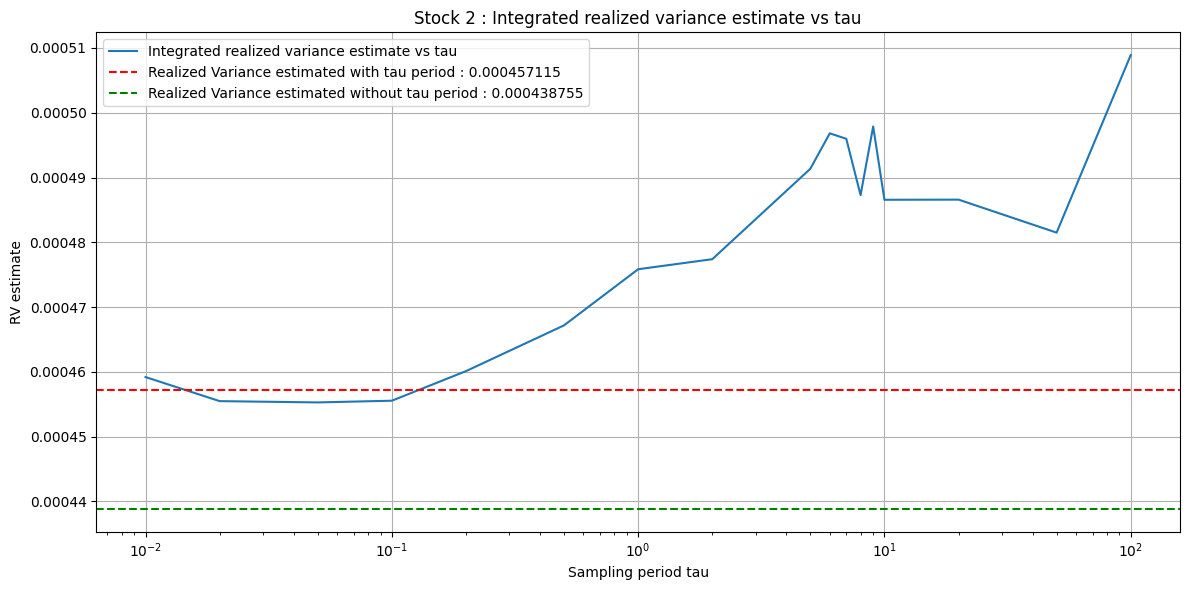

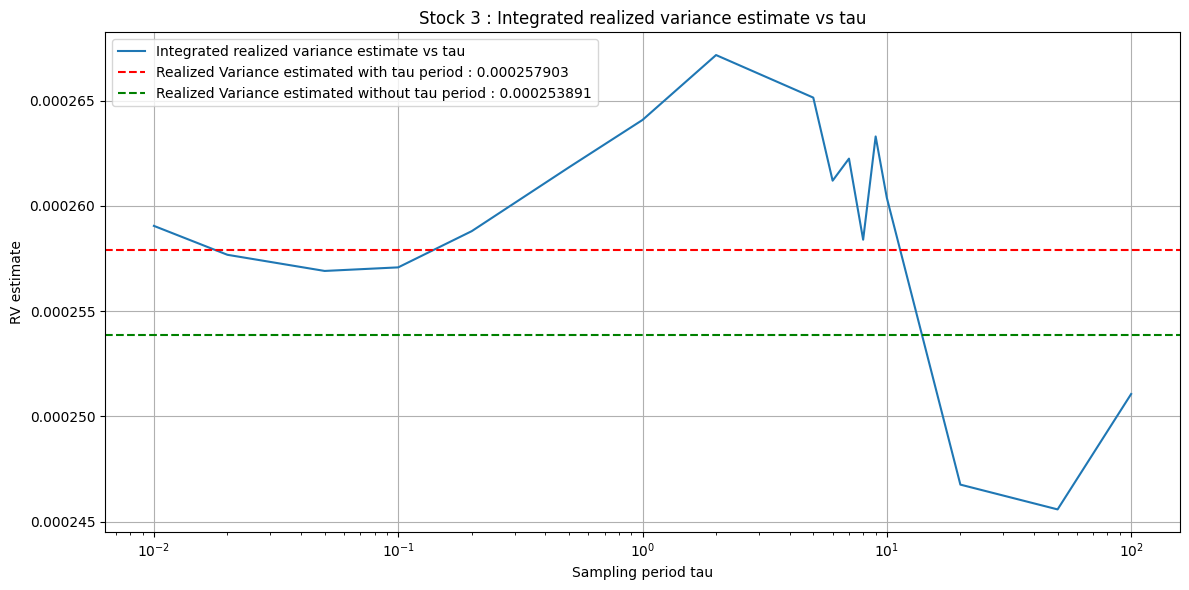

In [13]:
rv_mean_list = []

for stock in range (len(stock_ids)):
    realized_variance = results_rv_tau[stock]
    rv_mean = np.mean(realized_variance[:5])
    rv_mean_list.append(rv_mean)
    plt.figure(figsize=(12,6))
    plt.plot(tau_values,realized_variance,label="Integrated realized variance estimate vs tau")
    plt.axhline(rv_mean,linestyle='--',color='red',label=f'Realized Variance estimated with tau period : {rv_mean:.9f}')
    plt.axhline(results_rv[stock],linestyle='--',color='green',label=f'Realized Variance estimated without tau period : {(results_rv[stock]):.9f}')
    plt.xlabel("Sampling period tau")
    plt.ylabel("RV estimate")
    plt.xscale("log")
    plt.title(f"Stock {stock+1} : Integrated realized variance estimate vs tau")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [14]:
for stock in range (len(stock_ids)):
    a = abs(results_rv[stock]-rv_mean_list[stock])/results_rv[stock]
    print(f"Stock {stock+1} relative error of realized variance with vs without tau sampling : {a:.4f}")

Stock 1 relative error of realized variance with vs without tau sampling : 0.0342
Stock 2 relative error of realized variance with vs without tau sampling : 0.0418
Stock 3 relative error of realized variance with vs without tau sampling : 0.0158


In the plots above, we compare the realized variance computed with $\tau$ periods, to the mean of the smallest $\tau$ values (as it should converge with $\tau \rightarrow 0$), to the integrated realized variance without using $\tau$ sampling period, just by computing the mean over the 5 days of $\sum _t \log (\dfrac{P_{t+1}}{P_t})^2$ event-type based price.

We get that the result are very close relatively, as shown with the small relative errors computed above (less than 5% for all the stocks). They seem to converge (or at least have a reduced variance, as seen with Epps effect) when using lower valeus of sampling period.

**In the following sections we will be using directly the realized variance computed not using $\tau$ sampling.**

This means we can use both methods to estimate the standard covariance using $\tau$ period sampling for the standard estimator, and without $\tau$ sampling for the Hayashi-Yoshida estimator.



In [43]:
def HY_covariance_estimate(df1,df2):
    t0_stx1 = df1["ts"].iloc[0]
    T1_obs = (df1["ts"]-t0_stx1).dt.total_seconds().values
    p1_obs = np.log(df1["price"].values)
    t0_stx2 = df2["ts"].iloc[0]
    T2_obs = (df2["ts"]-t0_stx2).dt.total_seconds().values
    p2_obs = np.log(df2["price"].values)
    n1 = len(T1_obs)
    n2 = len(T2_obs)
    estimator = 0
    for i in range (1,n1):
        for j in range(1,n2):
            if not (T2_obs[j] < T1_obs[i-1] or T1_obs[i] < T2_obs[j-1]): # For [t1,t2] and [t3,t4], if t2 < t3 or t4 < t1, no intersection
                delta_p1 = p1_obs[i]-p1_obs[i-1]
                delta_p2 = p2_obs[j]-p2_obs[j-1]
                estimator = estimator + delta_p1*delta_p2
    return(estimator)

def HY_covariance_vectorized(df1,df2):
    t0_stx1 = df1["ts"].iloc[0]
    T1_obs = (df1["ts"]-t0_stx1).dt.total_seconds().values
    p1_obs = np.log(df1["price"].values)
    t0_stx2 = df2["ts"].iloc[0]
    T2_obs = (df2["ts"]-t0_stx2).dt.total_seconds().values
    p2_obs = np.log(df2["price"].values)
    dp1 = np.diff(p1_obs)
    a = T1_obs[:-1]
    b = T1_obs[1:]
    dp2 = np.diff(p2_obs)
    c = T2_obs[:-1]
    d = T2_obs[1:]
    result = 0
    for i in range(len(dp1)):
        j_min = np.searchsorted(d,a[i],side='left')
        j_max = np.searchsorted(c,b[i],side='right')-1
        if j_min <= j_max:
            result += dp1[i]*dp2[j_min:j_max+1].sum()
    return result

def standard_covariance_estimate(df1,df2,tau):
    t0_stx1 = df1["ts"].iloc[0]
    T1 = (df1["ts"].iloc[-1]-t0_stx1).total_seconds()
    T1_obs = (df1["ts"]-t0_stx1).dt.total_seconds().values
    p1_obs = np.log(df1["price"].values)
    t0_stx2 = df2["ts"].iloc[0]
    T2 = (df2["ts"].iloc[-1]-t0_stx2).total_seconds()
    T2_obs = (df2["ts"]-t0_stx2).dt.total_seconds().values
    p2_obs = np.log(df2["price"].values)
    m = int(min(T1,T2)/tau)
    realized_covariance = 0
    for i in range (1,m+1):
        idx_i_tau_stx1 = np.searchsorted(T1_obs,i*tau,side='right')-1
        idx_i_minus_one_tau_stx1 = np.searchsorted(T1_obs,(i-1)*tau,side='right')-1
        idx_i_tau_stx2 = np.searchsorted(T2_obs,i*tau,side='right')-1
        idx_i_minus_one_tau_stx2 = np.searchsorted(T2_obs,(i-1)*tau,side='right')-1
        if idx_i_tau_stx1 < 0 or idx_i_minus_one_tau_stx1 < 0 or idx_i_tau_stx2 < 0 or idx_i_minus_one_tau_stx2 < 0:
            continue
        realized_covariance += (p1_obs[idx_i_tau_stx1]-p1_obs[idx_i_minus_one_tau_stx1])*(p2_obs[idx_i_tau_stx2]-p2_obs[idx_i_minus_one_tau_stx2])
    return realized_covariance

Once we have the covariance estimators, we average the estimates over the 5 days, then we normalize the result using the realized variances computed over the 5 days. 

In [39]:
pairs = [(0,1),(0,2),(1,2)]
standard_correlation_tau = {}
for (stx1,stx2) in pairs:
    print(f"Stock {stx1+1} vs Stock {stx2+1} computation...")
    correlation_tau = []
    for tau in tau_values:
        cov_estimates = [standard_covariance_estimate(trades[stx1,day],trades[stx2,day],tau) for day in range(len(day_ids))]
        cov_avg = np.mean(cov_estimates)
        correlation_tau.append(cov_avg/np.sqrt(results_rv[stx1]*results_rv[stx2]))
    standard_correlation_tau[(stx1,stx2)] = correlation_tau

Stock 1 vs Stock 2 computation...
Stock 1 vs Stock 3 computation...
Stock 2 vs Stock 3 computation...


In [44]:
hy_correlation = {}
for (stx1,stx2) in pairs:
    print(f"Stock {stx1+1} vs Stock {stx2+1} computation...")
    cov_estimates = [HY_covariance_vectorized(trades[stx1,day],trades[stx2,day]) for day in range(len(day_ids))]
    cov_avg = np.mean(cov_estimates)
    hy_correlation[(stx1,stx2)] = cov_avg/np.sqrt(results_rv[stx1]*results_rv[stx2])

Stock 1 vs Stock 2 computation...
Stock 1 vs Stock 3 computation...
Stock 2 vs Stock 3 computation...


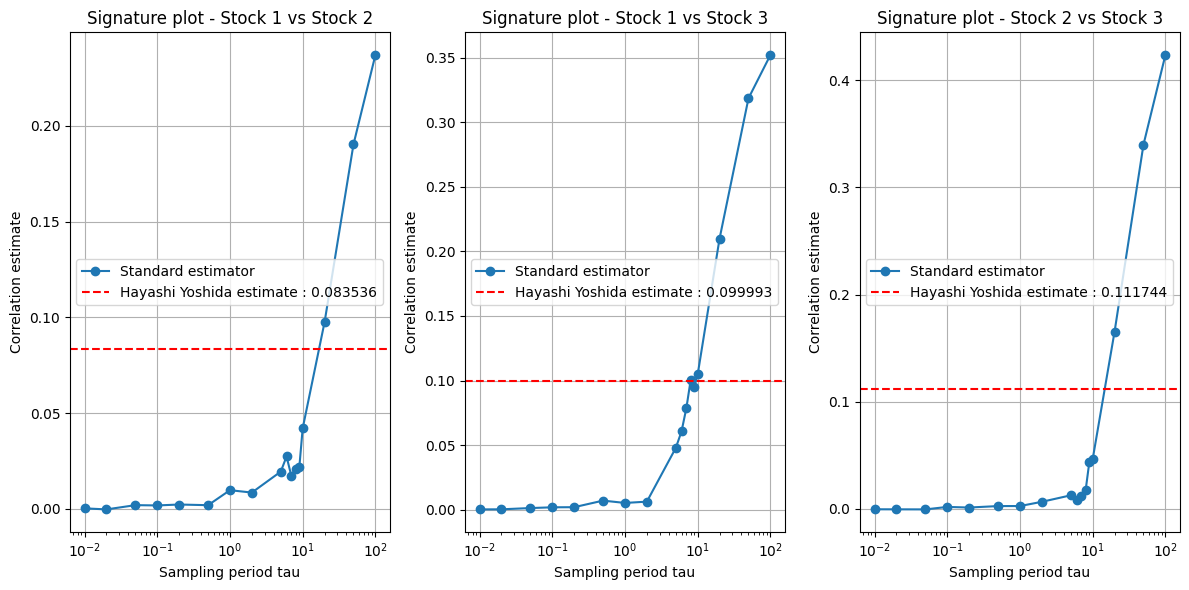

In [45]:
fig,axes = plt.subplots(1,3,figsize=(12,6))
for ax, (stx1,stx2) in zip(axes,pairs):
    ax.plot(tau_values, standard_correlation_tau[(stx1,stx2)], "o-", label='Standard estimator')
    ax.axhline(hy_correlation[(stx1,stx2)], color='red', linestyle='--', label=f"Hayashi Yoshida estimate : {hy_correlation[(stx1,stx2)]:.6f}")
    ax.set_xscale("log")
    ax.set_xlabel("Sampling period tau")
    ax.set_ylabel("Correlation estimate")
    ax.set_title(f"Signature plot - Stock {stx1+1} vs Stock {stx2+1}")
    ax.legend()
    ax.grid(True)
plt.tight_layout()
plt.show()

From the above graphs, the signature plots confirm the Epps effect mentionned previously on real data. 

When $\tau \rightarrow 0$ the standard estimator is strongly biased toward 0 as the two stocks are rarely observed in the same time window of $\tau$ period, the estimator returns no-correlation between the stocks. However, when $\tau$ increases, the standard estimator should converge to the expected value (obtained from the Hayashi-Yoshida estimate), but variance increases, as shown with the previous simulations which explains why the standard estimator fails.  

For intermediate values of $\tau$, between 5 and 15, the standard estimator may lead to correct results close to the Hayashi-Yoshida estimator.

The Hayashi-Yoshida doesn't require sampling period and is unaffected by the Epps effect while remaining an efficient estimate of the correlation between two stocks.

___

### 3. Lead-lag estimation

We wish to estimate for each pair of stock the lead-lag relationship using the Hayashi-Yoshida estimators.

To do this, we will compute using the Hayashi-Yoshida estimator : $ \quad \hat{l} = \argmax _l \widehat{[p_1,p_2^{(l)}]_T}$ 

Since the estimator is very costly to compute, we will use a vectorized form to make the computation faster.

A positive value of $\hat{l}$ means that stock 1 leads stock 2, because the movements are synchronized when stock 2 is being shifted in the future.

A negative value on the contrary means that stock 2 leads stock 1.

Instead of using a grid, since we don't know beforehand the scale of the lead-lag, we will use scipy.optimize to find the best value for $\hat{l}$ which maximizes our Hayashi-Yoshida estimator, which is equivalent to minimizing : $\quad - \widehat{[p_1,p_2^{(l)}]_T}$ 

In [46]:
def HY_covariance_shifted_vectorized(df1,df2,l):
    t0_stx1 = df1["ts"].iloc[0]
    T1_obs = (df1["ts"]-t0_stx1).dt.total_seconds().values
    p1_obs = np.log(df1["price"].values)
    t0_stx2 = df2["ts"].iloc[0]
    T2_obs = (df2["ts"]-t0_stx2).dt.total_seconds().values + l # We add the shift here
    p2_obs = np.log(df2["price"].values)
    dp1 = np.diff(p1_obs)
    a = T1_obs[:-1]
    b = T1_obs[1:]
    dp2 = np.diff(p2_obs)
    c = T2_obs[:-1]
    d = T2_obs[1:]
    result = 0
    for i in range(len(dp1)):
        j_min = np.searchsorted(d,a[i],side='left')
        j_max = np.searchsorted(c,b[i],side='right')-1
        if j_min <= j_max:
            result += dp1[i]*dp2[j_min:j_max+1].sum()
    return result

The code above basically applied the mask as used before :

For $[t_1,t_2]$ and $[t_3,t_4]$, if $t_2 < t_3$ or $t_4 < t_1$, no intersection

The different modifications for this function (and more further on) are due to the high time computation.

In [47]:
lead_lags = []
for (stx1,stx2) in pairs:
    print(f"Computing lead-lag for Stock {stx1+1} vs Stock {stx2+1}")
    def objective_function(l):
        HY_cov_values = []
        for day in range (len(day_ids)):
            df1 = trades[stx1,day]
            df2 = trades[stx2,day]
            HY_cov_values.append(HY_covariance_shifted_vectorized(df1,df2,l))
        return(-np.mean(HY_cov_values))
    res = minimize_scalar(objective_function,bounds=(-20,20),method='bounded')
    lead_lag = res.x
    lead_lags.append(lead_lag)
    if lead_lag > 0:
        print(f"Stock {stx1+1} leads Stock {stx2+1} with lead-lag of {lead_lag:.6f}")
    elif lead_lag < 0:
        print(f"Stock {stx2+1} leads Stock {stx1+1} with lead-lag of {-lead_lag:.6f}")
    else :
        print(f"No lead lag for Stock {stx1+1} vs Stock {stx2+1}")

Computing lead-lag for Stock 1 vs Stock 2
Stock 2 leads Stock 1 with lead-lag of 12.388133
Computing lead-lag for Stock 1 vs Stock 3
Stock 3 leads Stock 1 with lead-lag of 3.496444
Computing lead-lag for Stock 2 vs Stock 3
Stock 2 leads Stock 3 with lead-lag of 8.026831


In a sense, we could say that stock 1 is the "slowest" stock of the 3 stocks as it is lead by both stock 2 and stock 3.

Stock 2 is the most important stock, as it leads both stock 1 and stock 3, which means the impacts on stock 2 are being transferred with a lag of 12.4s and 8s to stock 1 and 3 respectively.

We also have a satisfaying result, which is that the lag between stock 1 and stock 3 plus the lag from stock 3 to stock 2 is close to the lag from stock 1 to stock 2 :

$12.39 \sim 12.53 = 3.50 + 8.03$

Given this value, we will use a grid between -20 and +20 seconds to make the plot :

In [48]:
lag_grid = np.arange(-20,20,0.1)
lead_lag_curves = {}
for (stx1,stx2) in pairs:
    print(f"Computing lead-lag for Stock {stx1+1} vs Stock {stx2+1}")
    hy_lags = []
    for lag in lag_grid:
        values = [HY_covariance_shifted_vectorized(trades[stx1,day],trades[stx2,day],lag) for day in range (len(day_ids))]
        hy_lags.append(np.mean(values))
    lead_lag_curves[(stx1,stx2)] = hy_lags

Computing lead-lag for Stock 1 vs Stock 2
Computing lead-lag for Stock 1 vs Stock 3
Computing lead-lag for Stock 2 vs Stock 3


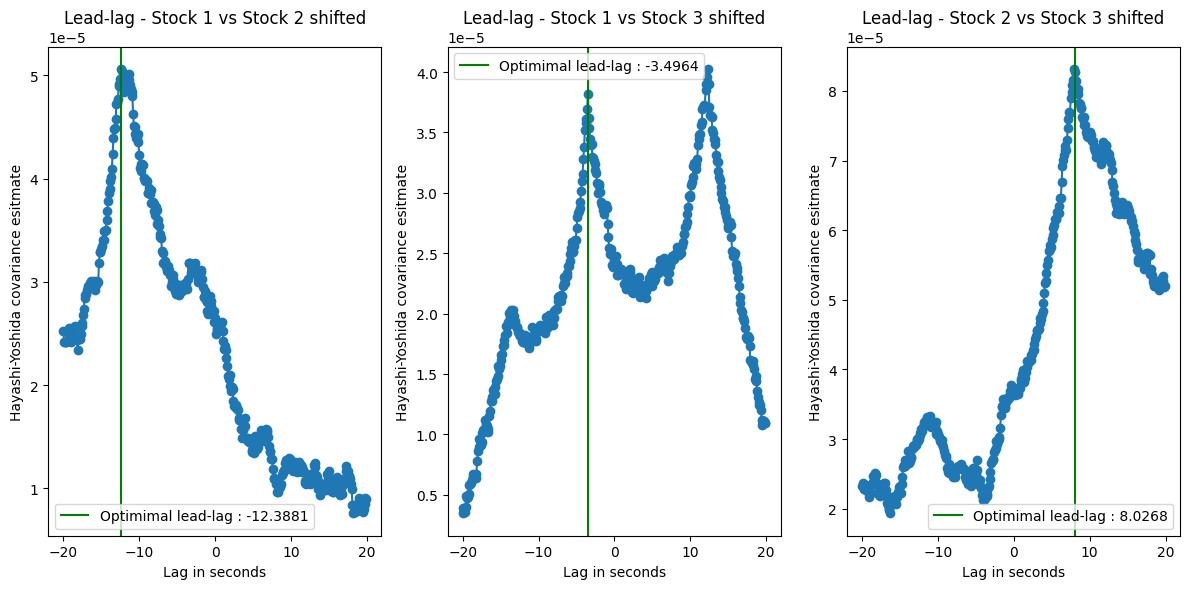

In [49]:
fig, axes = plt.subplots(1,3,figsize=(12,6))
for ax, (stx1,stx2) in zip(axes,pairs):
    values = lead_lag_curves[(stx1,stx2)]
    lead_lag = lead_lags[pairs.index((stx1,stx2))]
    ax.plot(lag_grid, values, "o-")
    ax.axvline(lead_lag, color='green',label=f'Optimimal lead-lag : {lead_lag:.4f}')
    ax.set_xlabel("Lag in seconds")
    ax.set_ylabel("Hayashi-Yoshida covariance esitmate")
    ax.set_title(f"Lead-lag - Stock {stx1+1} vs Stock {stx2+1} shifted")
    ax.legend()
plt.tight_layout()
plt.show()

For stock 3 vs stock 1, there seems to be 2 lead-lag values that are standing out, with the optimizer giving the out in green as the highest when computing with fine-precision.

This could mean that both stocks are influencing one another, as the two lags stock 1 vs stock 3 shifted are being respectively $-3.5s$ and $\sim 13s$.

___

### 4. Hawkes process for trades

We will be trying to fit a univariate Hawkes process with exponential Kernel for the time dynamics of the trades on our datasets :

$\lambda (t) = \mu + \alpha \int _0 ^t e ^{- \beta (t-s)} dN_s \qquad \mu, \alpha, \beta > 0$

We will fit the different parameters using EM algorithm as seen in lab 3, and MLE using the log-likelihood function.

We have that  for a Hawkes process on $[0,T]$ :

$\log \mathcal{L} (\mu, \alpha, \beta) = \sum _{k=1} ^N \log \lambda (t_k) - \int _0 ^T \lambda (s) ds$

For the goodness-of-fit, we will be using the time-change theorem, where the compensated inter-arrivals times should be i.i.d and follow the exponential distribution $\mathcal{E}(1)$.

In [66]:
MAX_BOUND = 500000

def hawkes_log_likelihood(events, T_end, mu, alpha, beta):
    events = np.asarray(events, dtype=float)
    N = len(events)
    log_likelihood = 0
    A = 0
    for i in range(N):
        if i>0:
            A = np.exp(-beta * (events[i]-events[i-1]))*(1+A)
        lambda_i = mu + alpha * A
        if lambda_i <= 0:
            return(np.inf)
        log_likelihood += np.log(lambda_i)
    integral_term = (mu*T_end + (alpha/beta)*np.sum(1-np.exp(-beta*(T_end-events))))
    return log_likelihood - integral_term

def em_hawkes_exp(events, T_end, init_params, n_iter=20):
    mu, alpha, beta = init_params
    N = len(events)
    events = np.array(events)
    for _ in range(n_iter):
        A = 0
        B = 0
        sum_pij = 0
        sum_pij_dt = 0
        sum_pjj = 0
        for i in range (N):
            if i > 0 :
                dt = events[i]-events[i-1]
                B = np.exp(-beta*dt)*(B+dt*(1+A))
                A = np.exp(-beta*dt)*(1+A)
            lambda_i = mu + alpha*A
            p_jj = mu/lambda_i
            sum_pjj += p_jj
            if i >0:
                pij_total = alpha*A/lambda_i
                sum_pij += pij_total
                sum_pij_dt += alpha*B/lambda_i
        mu = sum_pjj / T_end
        if sum_pij_dt > 0:
            beta = min(sum_pij / sum_pij_dt,MAX_BOUND)
        survival = np.sum(1 - np.exp(-beta*(T_end - events)))
        if survival > 0:
            alpha = beta*sum_pij/survival
    return mu, alpha, beta

def mle_hawkes_exp(events,T_end,init_params):
    events = np.asarray(events,dtype=float)
    def neg_ll(params):
        mu, alpha, beta = params
        if mu <= 0 or alpha <= 0 or beta <= 0:
            return np.inf
        return -hawkes_log_likelihood(events,T_end,mu,alpha,beta)
    res = optimize.minimize(neg_ll, init_params, method="L-BFGS-B",bounds=[(1e-6,1000),(1e-6,MAX_BOUND),(1e-6,MAX_BOUND)],options={"maxiter":50})
    return tuple(res.x)

def compensated_inter_arrival_times(events,mu,alpha,beta):
    events = np.asarray(events,dtype=float)
    A = 0
    result = []
    for i in range(1,len(events)):
        dt = events[i] if i==0 else events[i]-events[i-1]
        A_prev = A
        A = np.exp(-beta*dt)*(1+A_prev)
        dL = mu*dt + (alpha/beta)*(1+A_prev)*(1-np.exp(-beta*dt))
        result.append(dL)
    return(result)


Using the functions defined above, we optimize our parameters.

In [67]:
params_em = {}
params_mle = {}
for stock in range(len(stock_ids)):
    print(f"Stock {stock+1} fitting...")
    mus_em, alphas_em, betas_em = [], [], []
    mus_mle, alphas_mle, betas_mle = [], [], []
    for day in range(len(day_ids)):
        print(f"Day {day+1}")
        df = trades[stock,day]
        t0 = df["ts"].iloc[0]
        events = (df["ts"]-t0).dt.total_seconds().values
        T_end = float(events[-1])
        rate0 = len(events)/T_end
        init = [rate0*0.1, 0.1, 1.0]
        mu_em, alpha_em, beta_em = em_hawkes_exp(events, T_end, init)
        mus_em.append(mu_em); alphas_em.append(alpha_em); betas_em.append(beta_em)
        # Starting MLE from EM result for faster convergence
        mu_ml, alpha_ml, beta_ml = mle_hawkes_exp(events, T_end, [mu_em, alpha_em, beta_em])
        mus_mle.append(mu_ml); alphas_mle.append(alpha_ml); betas_mle.append(beta_ml)
    params_em[stock] = dict(mu=np.mean(mus_em),alpha=np.mean(alphas_em),beta=np.mean(betas_em))
    params_mle[stock] = dict(mu=np.mean(mus_mle),alpha=np.mean(alphas_mle),beta=np.mean(betas_mle))
    print(f"Stock {stock+1} parameters obtained : \n")
    print(f"EM method : mu = {np.mean(mus_em):.3f} \t alpha = {np.mean(alphas_em):.3f} \t beta = {np.mean(betas_em):.3f}")
    print(f"MLE method : mu = {np.mean(mus_mle):.3f} \t alpha = {np.mean(alphas_mle):.3f} \t beta = {np.mean(betas_mle):.3f}\n")

Stock 1 fitting...
Day 1
Day 2
Day 3
Day 4
Day 5
Stock 1 parameters obtained : 

EM method : mu = 0.426 	 alpha = 114825.493 	 beta = 212472.152
MLE method : mu = 0.432 	 alpha = 114825.493 	 beta = 212472.152

Stock 2 fitting...
Day 1
Day 2
Day 3
Day 4
Day 5
Stock 2 parameters obtained : 

EM method : mu = 0.126 	 alpha = 34200.501 	 beta = 70500.029
MLE method : mu = 0.126 	 alpha = 34200.501 	 beta = 70500.029

Stock 3 fitting...
Day 1
Day 2
Day 3
Day 4
Day 5
Stock 3 parameters obtained : 

EM method : mu = 0.264 	 alpha = 246703.093 	 beta = 500000.000
MLE method : mu = 0.264 	 alpha = 246703.093 	 beta = 500000.000



We plot the results using the two methods for each of our 3 stocks :

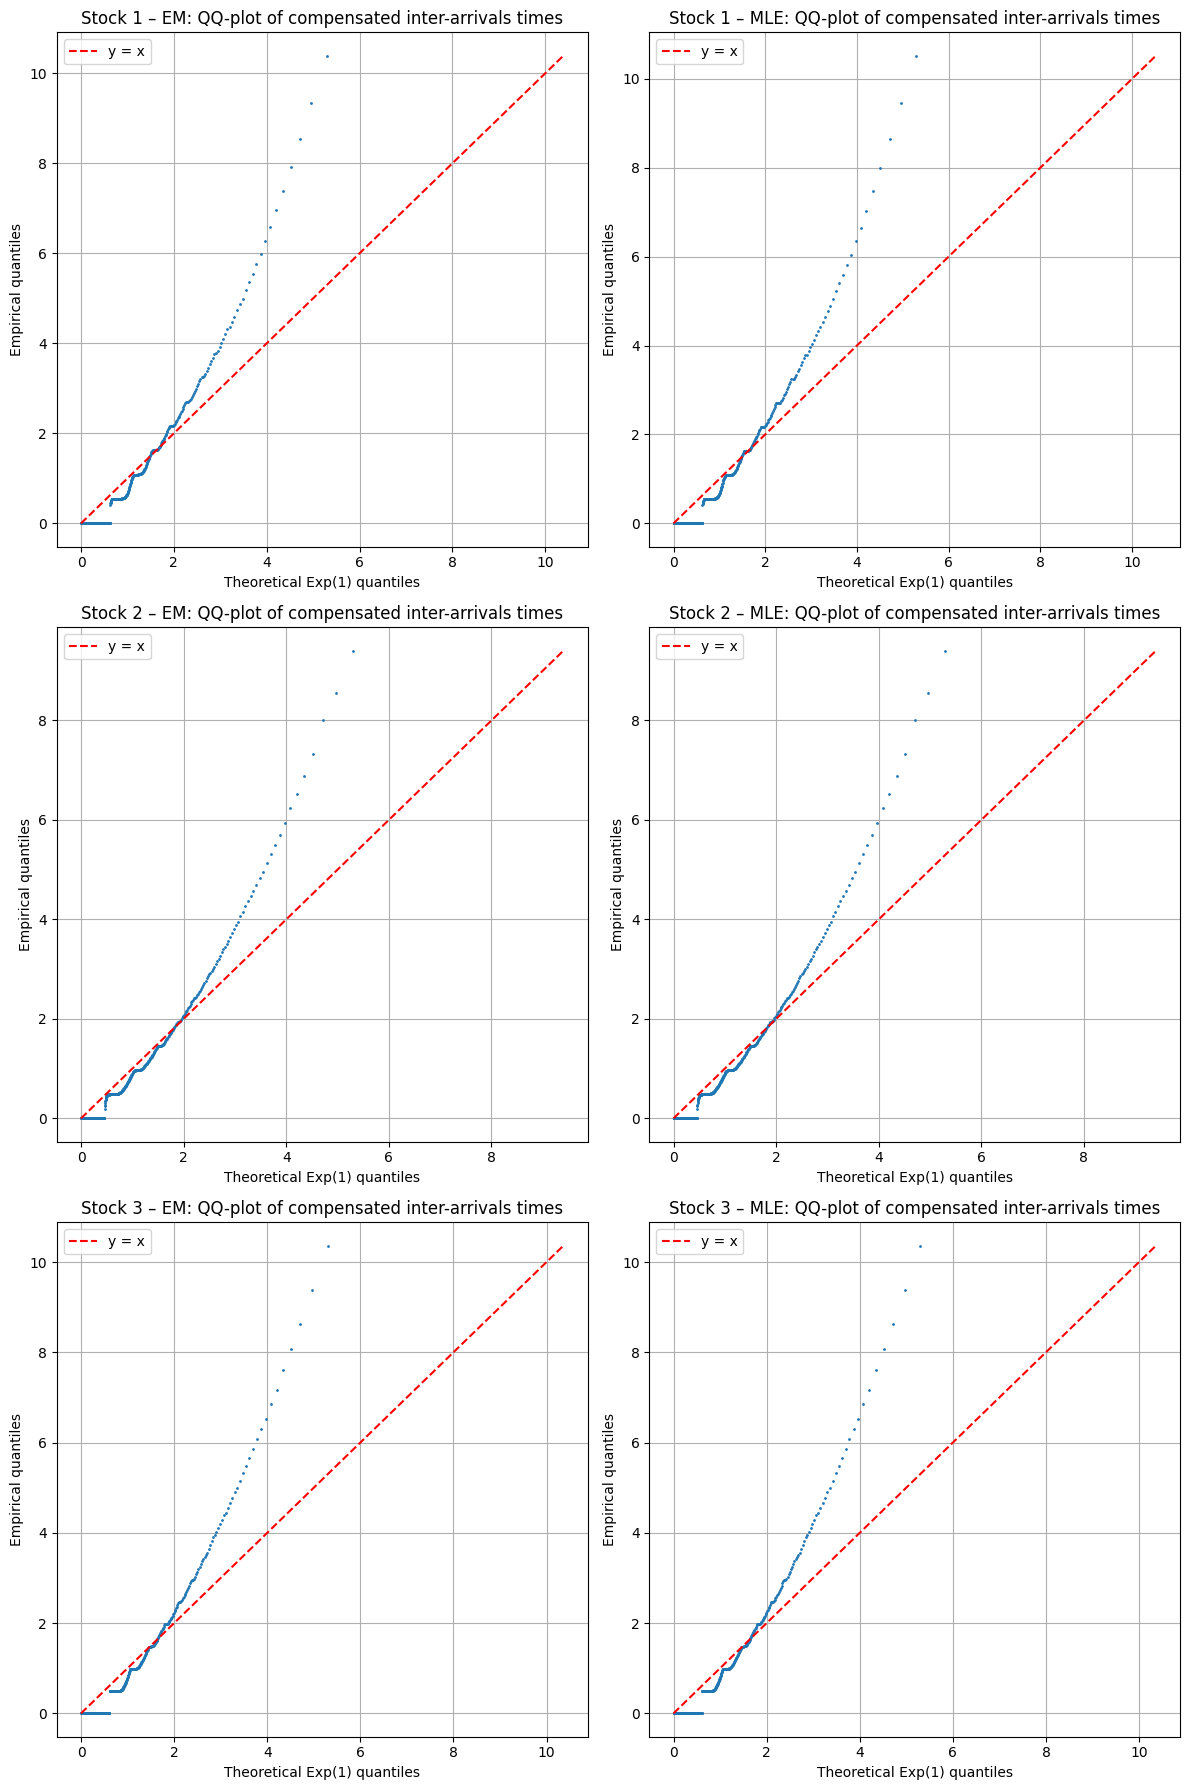

In [69]:
fig, axes = plt.subplots(len(stock_ids), 2, figsize=(12, 6*len(stock_ids)))
quantiles = np.linspace(0.005, 0.995, 500)

for s in range(len(stock_ids)):
    for col, (label, pdict) in enumerate([("EM", params_em[s]),("MLE", params_mle[s])]):
        resid_all = []
        for day in range(len(day_ids)):
            df = trades[s, day]
            t0 = df["ts"].iloc[0]
            events = (df["ts"] - t0).dt.total_seconds().values
            T_end = float(events[-1])
            resid_all.extend(compensated_inter_arrival_times(events,pdict["mu"],pdict["alpha"],pdict["beta"]))
        resid_all = np.array(resid_all)
        empirical_quantiles = np.quantile(resid_all,quantiles)
        theoretical_quantiles = stats.expon.ppf(quantiles)
        lim = max(theoretical_quantiles.max(), empirical_quantiles.max())
        ax = axes[s, col]
        ax.plot(theoretical_quantiles, empirical_quantiles, ".", ms=2)
        ax.plot([0, lim], [0, lim], "r--", label="y = x")
        ax.set_xlabel("Theoretical Exp(1) quantiles")
        ax.set_ylabel("Empirical quantiles")
        ax.set_title(f"Stock {s+1} – {label}: QQ-plot of compensated inter-arrivals times")
        ax.legend(); ax.grid(True)

plt.tight_layout()
plt.show()

The results from the QQ-plot show that for low quantiles, the model somehow fits, however for higher quantiles the model does not correctly fits our data and does not yield the expected results.

We can see that the parameters also reach the maximum bound for stock 3 before finishing optimizing, and that both methods reach this local maximal value for log-likelihood, which is somewhat satisfaying seeing that both EM and MLE yield the same results.

___

### 5. Hawkes fit on signature plots

The Hawkes model from the paper "Modeling microstructure noise with mutually exciting point processes" is the following, coming from proposition 2.1 :

$C(\tau) = \Lambda ( \kappa ^2 + (1 - \kappa ^2) \dfrac{1 - e ^{-\gamma \tau}}{\gamma \tau})$

With : $\quad \Lambda = \dfrac{2 \mu}{1 - \alpha / \beta}, \kappa = \dfrac{1}{1+\alpha / \beta}, \gamma = \alpha + \beta$

By using $\psi (t) = \alpha e ^{-\beta t} \mathbb{1}_{\mathbb{R}^+}(t)$

We can see that $C(\tau)$ is decreasing from $C(\tau) _{\tau \rightarrow 0} \rightarrow \Lambda$ to $C(\tau) _{\tau \rightarrow + \infty} \rightarrow \Lambda \kappa ^2$, so the model predicts a decreasing function for the signature plot.

The litterature suggests that :
- $C(0) = \Lambda$ is the microstructure variance
- $C(+ \infty) = \Lambda \kappa ^2$ is the diffusive variance
- $\dfrac{1}{\gamma}$ is the mean-reversion time-scale

The paper uses MLE to estimate the parameters $(\mu,\alpha,\beta)$, as seen in question 4, or a regression estimator $\hat{\theta}$ which we won't be using.

Stock 1 :
mu = 0.43201 	 alpha = 114825.49274 	 beta = 212472.15230
Stock 2 :
mu = 0.12572 	 alpha = 34200.50070 	 beta = 70500.02865
Stock 3 :
mu = 0.26402 	 alpha = 246703.09309 	 beta = 500000.00000


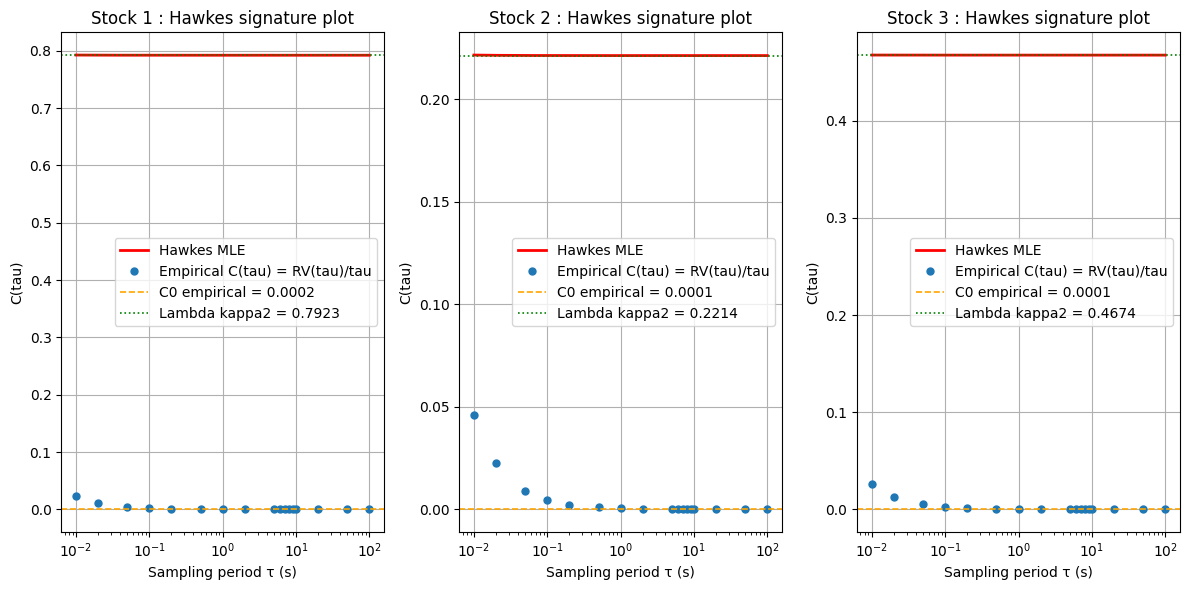

In [70]:
def C_hawkes(tau, mu, alpha, beta):
    tau = np.asarray(tau, dtype=float)
    n = alpha/beta
    lam = 2*mu/(1-n)
    kappa = 1/(1+n)
    gamma = alpha + beta
    return lam*(kappa**2 + (1-kappa**2) * (1-np.exp(-gamma*tau)) / (gamma*tau))

tau_array  = np.array(tau_values)
tau_fine = np.logspace(np.log10(tau_array[0]), np.log10(tau_array[-1]), 400)
fig, axes = plt.subplots(1, len(stock_ids), figsize=(12, 6))

for stock, ax in enumerate(axes):
    p = params_mle[stock]
    mu, alpha, beta = p["mu"], p["alpha"], p["beta"]
    n = alpha/beta
    Lam = 2*mu / (1-n)
    kappa = 1 / (1+n)
    gamma = alpha + beta
    C_empirical = np.array(results_rv_tau[stock])/tau_array
    rates = []
    for day in range(len(day_ids)):
        df = trades[stock,day]
        t0 = df["ts"].iloc[0]
        T_day = (df["ts"].iloc[-1]-t0).total_seconds()
        rates.append(len(df)/T_day)
    mean_rate = np.mean(rates)
    C0_empirical = results_rv[stock]*mean_rate
    ax.plot(tau_fine, C_hawkes(tau_fine, mu, alpha, beta),"-", lw=2, color="red", label=f"Hawkes MLE")
    ax.plot(tau_array, C_empirical, "o", ms=5, label = 'Empirical C(tau) = RV(tau)/tau')
    ax.axhline(C0_empirical, color="orange", linestyle="--", lw=1.2, label=f"C0 empirical = {C0_empirical:.4f}")
    ax.axhline(Lam*kappa**2, color="green", linestyle=":", lw=1.2, label=f"Lambda kappa2 = {Lam*kappa**2:.4f}")
    ax.set_xscale("log")
    ax.set_xlabel("Sampling period τ (s)")
    ax.set_ylabel("C(tau)")
    ax.set_title(f"Stock {stock+1} : Hawkes signature plot")
    ax.legend()
    ax.grid(True)

    print(f"Stock {stock+1} :")
    print(f"mu = {mu:.5f} \t alpha = {alpha:.5f} \t beta = {beta:.5f}")
plt.tight_layout()
plt.show()

The above graphs present the theoretical vs empirical signature curves. They do not match at all, the empirical C(0) being very close to 0 as explained before with the realized variance being very close to 0 because of the Epps effect.